In [162]:
import os
import pandas as pd
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st # for Cumulative Distribution Function in VdW score 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

Load the data (download pre_processing.csv from ".....")

In [163]:
df = pd.read_parquet('datasets/pre_processing.parquet')

Keep data with listings over 11 years

In [164]:
# count number of years per id
obs_per_id = df.groupby(['mun_istat'])['year'].nunique()

# count how many ids have 1 year, 2 years, etc.
count_by_years = obs_per_id.value_counts().sort_index()

print(count_by_years)

year
1        2
2        1
3       21
4        5
5        1
7       38
8        7
9        6
10      21
11    7771
Name: count, dtype: int64


In [165]:
# keep only ids with listings over 11 years - balanced panel data
ids_eleven = obs_per_id[obs_per_id == 11].index

# filter the data
df = df[df['mun_istat'].isin(ids_eleven)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mun_istat                85481 non-null  object  
 1   year                     85481 non-null  int64   
 2   mun_name                 85481 non-null  object  
 3   mun_name_norm            85481 non-null  object  
 4   location                 85481 non-null  category
 5   region                   85481 non-null  object  
 6   prov                     85481 non-null  object  
 7   buy_min                  85481 non-null  float64 
 8   buy_max                  85481 non-null  float64 
 9   prov_istat               85481 non-null  object  
 10  population               85481 non-null  float64 
 11  surface                  85481 non-null  float64 
 12  median_income            85481 non-null  float64 
 13  changed                  85481 non-null  bool    
 14  suppressed 

Cumulative data per province (population, dwellings, tourism values)

In [166]:
sum_col = ['population', 'dwellings', 'five_stars_count','four_stars_count','three_stars_count','two_stars_count','one_stars_count','holiday_dwelling_count','holiday_dwelling_beds','tot_count','tot_acc_beds','tot_beds','tot_arrivals_residents','tot_arrivals_foreigners','tot_arrivals','tot_nights_residents','tot_nights_foreigners','tot_nights']

for col in sum_col:
    df['prov_' + col] = df.groupby(['year', 'prov'], observed=True)[col].transform('sum')

Weighted averages per province (buy_min, buy_max, median_income)

In [167]:
# buy_min * dwellings
df['buy_min_fraction'] = (df['buy_min'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_min_wgt'] = df.groupby(['year','prov'], observed=True)['buy_min_fraction'].transform('sum')

# buy_max * dwellings
df['buy_max_fraction'] = (df['buy_max'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_max_wgt'] = df.groupby(['year','prov'], observed=True)['buy_max_fraction'].transform('sum')

# median_income * population
df['median_income_fraction'] = (df['median_income'] * df['population']) / df['prov_population']
df['prov_median_income_wgt'] = df.groupby(['year','prov'], observed=True)['median_income_fraction'].transform('sum')

# drop fraction cols
df = df.drop(columns = ['buy_min_fraction', 'buy_max_fraction', 'median_income_fraction'])

Immigration and emigration ratios

In [168]:
# total number of immigrants, emigrants, and net movements (standardized per 100 inhabitants) - SEMI-ELASTICITY
df['prov_immigration'] = ((df['abroad_in'] + df['nation_in']) / df['population']) * 100

df['prov_emigration'] = ((df['abroad_out'] + df['nation_out']) / df['population']) * 100

Tourism indexes

In [169]:
# total number of hotel beds
hotel_col = [
    'prov_five_stars_count',
    'prov_four_stars_count',
    'prov_three_stars_count',
    'prov_two_stars_count',
    'prov_one_stars_count'
]

df['prov_hotel_count'] = df[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df = df.drop(columns = hotel_col)

# two variables are computed for a better overview of hotel presence in a municipality
# HOTEL PRESSURE ON TOURISM SECTOR - ratio between hotel beds (total beds - other accomodations bed) and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_hotel_beds'] = np.where(df['prov_tot_beds'] == 0, 0, ((df['prov_tot_beds'] - df['prov_tot_acc_beds']) / df['prov_tot_beds']) * 100)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_hotel_mun'] = ((df['prov_tot_beds'] - df['prov_tot_acc_beds']) / df['prov_population']) * 100

###

# three variables are computed for a better overview of holiday dwellings impact on the tourism sector and on municipalities
# STR PRESSURE ON TOURISM SECTOR - ratio between holiday dwellings bed and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_beds'] = np.where(df['prov_tot_beds'] == 0, 0, (df['prov_holiday_dwelling_beds'] / df['prov_tot_beds']) * 100) 

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_mun'] = (df['prov_holiday_dwelling_count'] / df['prov_dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_mun_beds'] = (df['prov_holiday_dwelling_beds'] / df['prov_population']) * 100

###

# measure the ratio between total arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_arrivals'] = (df['prov_tot_arrivals'] / df['prov_population']) * 100

# measure the ratio between total foreigner arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_arrivals_foreigners'] = (df['prov_tot_arrivals_foreigners'] / df['prov_population']) * 100

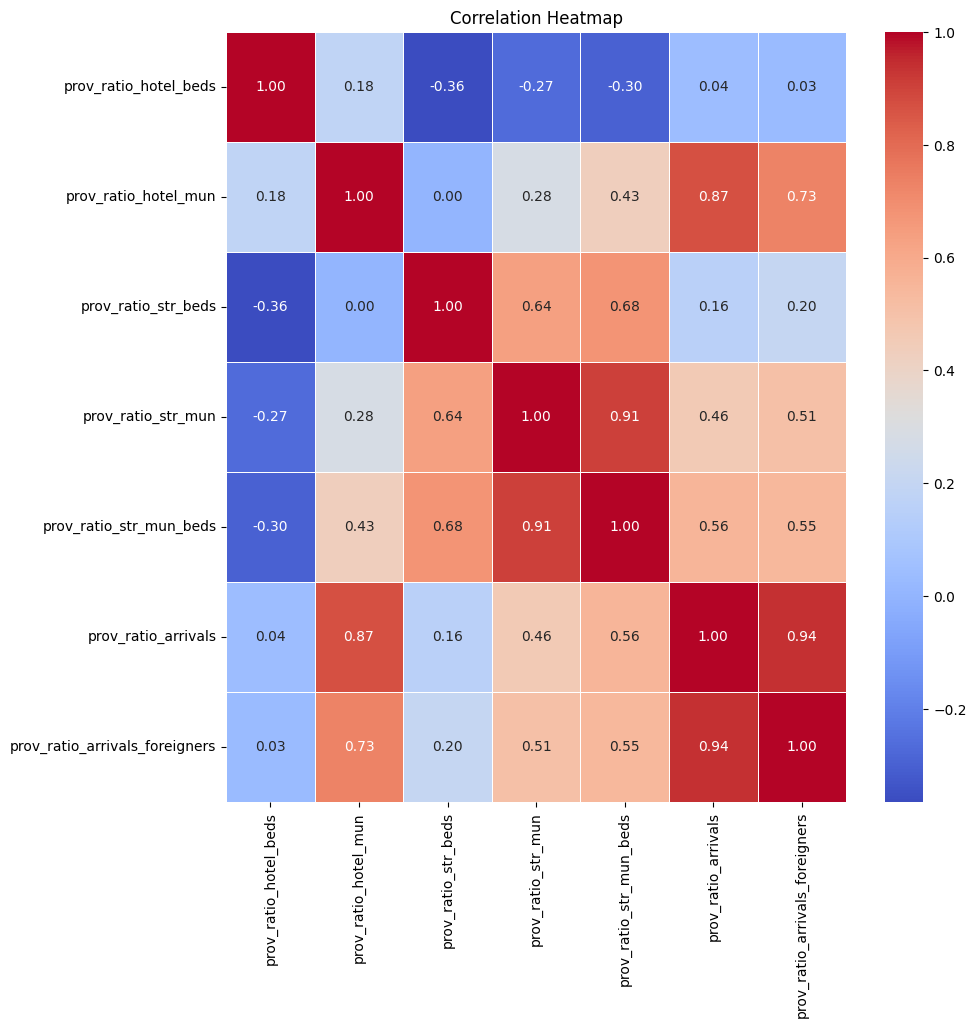

In [170]:
# correlation matrix
# Correlation matrix
var_corr = [
    'prov_ratio_hotel_beds',
    'prov_ratio_hotel_mun',
    'prov_ratio_str_beds',
    'prov_ratio_str_mun',
    'prov_ratio_str_mun_beds',
    'prov_ratio_arrivals',
    'prov_ratio_arrivals_foreigners'
]

matrix = df[var_corr].corr()

plt.figure(figsize=(10,10))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [171]:
# compute Van der Waerden score as a tourist index - consider prov_ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vdw_var = [
    'prov_ratio_hotel_mun',
    'prov_ratio_str_mun',
    'prov_ratio_str_mun_beds',
    'prov_ratio_arrivals',
    'prov_ratio_arrivals_foreigners'
]

for col in vdw_var:
    df[col + '_vdw'] = van_der_waerden_score(df[col])

# composite index based on VdW scores (average value)
df['tourism_index_vdw'] = df[[v + '_vdw' for v in vdw_var]].mean(axis=1)

In [172]:
# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_vdw'].min())
print("Maximum tourism score: ", df['tourism_index_vdw'].max())

Minimum tourism score:  2.2176598582157645
Maximum tourism score:  98.51781661636369


In [173]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize
X = StandardScaler().fit_transform(df[vars_tourism])

# PCA with 1 component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)[:, 0]

# Variance explained
print("Variance explained by first component:", pca.explained_variance_ratio_[0])

# Shift to make positive
pc1_positive = pc1 - pc1.min() + 1e-6

# Scale 0–100
df['tourism_index_pca'] = 100 * (pc1_positive / pc1_positive.max())

Variance explained by first component: 0.7030094773454344


In [174]:
# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_pca'].min())
print("Maximum tourism score: ", df['tourism_index_pca'].max())

Minimum tourism score:  6.868940995342134e-06
Maximum tourism score:  100.0


Group by province

In [175]:
df_prov = df.groupby(['year','prov'], observed=True).agg({
    'location':'first',
    'region':'first',
    'prov_buy_min_wgt':'first',
    'prov_buy_max_wgt':'first',
    'prov_median_income_wgt':'first',
    'prov_population':'first',
    'prov_dwellings':'first',
    'prov_immigration':'first',
    'prov_emigration':'first',
    'prov_unemployment':'first',
    'reg_age_avg':'first',
    'prov_ratio_hotel_beds':'first',
    'prov_ratio_hotel_mun':'first',
    'prov_ratio_str_beds':'first',
    'prov_ratio_str_mun':'first',
    'prov_ratio_str_mun_beds':'first',
    'prov_ratio_arrivals':'first',
    'prov_ratio_arrivals_foreigners':'first',
    'tourism_index_vdw':'first',
    'tourism_index_pca':'first',
    'tour_employed':'first',
    'real_gdp':'first',
    'nominal_gdp':'first',
    'life':'first',
    'interest_rate':'first'
}).reset_index()

Log transform

In [180]:
log_col = ['prov_buy_min_wgt','prov_buy_max_wgt','prov_population','prov_dwellings','prov_median_income_wgt','prov_immigration','prov_emigration','tourism_index_vdw','tourism_index_pca','real_gdp','nominal_gdp','tour_employed','reg_age_avg','life','prov_unemployment','interest_rate']

for col in log_col:
    df_prov['log_' + col] = np.log(df_prov[col])

Growth rates

In [181]:
diff_col = ['log_prov_buy_min_wgt','log_prov_buy_max_wgt','log_prov_population','log_prov_median_income_wgt','log_prov_immigration','log_prov_emigration','log_tourism_index_vdw','log_tourism_index_pca','log_real_gdp','log_nominal_gdp','log_tour_employed','log_reg_age_avg','log_life','log_prov_unemployment','log_interest_rate']

for col in diff_col:
    df_prov['d_' + col] = df_prov.groupby('prov')[col].diff()

Save the data

In [182]:
df_prov.to_csv('datasets/model.csv', index = False)